In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install "zarr>=2.16.0,<3.0.0" numcodecs umap-learn

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.3/211.3 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 155.7 MB/s eta 0:00:00
  Created wheel for asciitree: filename=asciitree-0.3.3-py3-none-any.whl size=5031 sha256=d593fbdc376703e91d40386f32f1cb9b9c8e985d12e7adb9af5d3ef22ae7071e
  Stored in directory: /root/.cache/pip/wheels/a5/d7/98/f56ae733748cd0fa577172bda0e73e0b1f1793c98e09b9e458
Successfully built asciitree


In [3]:
import os
import shutil
import datetime
import gc
import numpy as np
import tensorflow as tf
import random
from typing import Literal
import matplotlib.pyplot as plt
import pandas as pd
import math
from dataclasses import dataclass
from collections.abc import Iterable
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [4]:
ModelType = Literal["pair", "triplet"]

@dataclass
class ModelConfig:
    type: ModelType

@dataclass
class DataConfig:
    authors_range: Iterable[int]
    original_shape: tuple[int, int, int]
    model_input_shape: tuple[int, int, int]

    def __post_init__(self):
        authors_array = np.asarray(list(self.authors_range))

        if authors_array.ndim != 1 or len(authors_array) == 0:
            raise ValueError("authors_range must be a non-empty 1D iterable")

        if len(np.unique(authors_array)) != len(authors_array):
            raise ValueError("authors_range contains duplicates")

        self.authors_range = authors_array
        self.authors = len(authors_array)


@dataclass
class TrainingConfig:
    epochs: int
    seed: int
    val_ratio: float

    def __post_init__(self):
        assert 0 < self.val_ratio < 1, "val_ratio must be between 0 and 1"


@dataclass
class BatchConfig:
    train: int
    validation: int
    test: int

    def __post_init__(self):
        assert self.train > 0
        assert self.validation > 0
        assert self.test > 0


@dataclass
class Config:
    project_path: str
    dataset: str
    model: ModelConfig
    data: DataConfig
    training: TrainingConfig
    batch: BatchConfig
    current_time: str

In [5]:
config = Config(
    project_path='drive/MyDrive/author-handwriting-recog',
    dataset='dataset_4_ImagesLinesRemoved_20260310-153450',
    model=ModelConfig(type="triplet"),
    data=DataConfig(
        authors_range=range(0, 5),
        original_shape=(180, 360, 1),
        model_input_shape=(120, 240, 3),
    ),
    training=TrainingConfig(
        epochs=30,
        seed=42,
        val_ratio=0.25
    ),
    batch=BatchConfig(
        train=4,
        validation=4,
        test=4,
    ),
    current_time=datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
)

In [6]:
def upload_source(source: str, source_dest: str):
    if os.path.exists(source_dest):
        shutil.rmtree(source_dest)

    shutil.copytree(source, source_dest)

In [7]:
src_drive = f"{config.project_path}/src"
src_local = "./src"

In [8]:
src_data_drive = f"{config.project_path}/data/datasets/180_360_90"
src_data_local = f"./dataset"

In [9]:
upload_source(source=src_drive, source_dest=src_local)

In [10]:
upload_source(source=src_data_drive, source_dest=src_data_local)

In [11]:
random.seed(config.training.seed)
np.random.seed(config.training.seed)
tf.random.set_seed(config.training.seed)

In [12]:
from src.io import LoggerFactory
from src.datasets.loaders import SelectiveDataLoader
from src.generators import (
    AugmentationPipeline,
    AugmentationOps,
    AugmentImage,
    BaseGenerator,
    DataGenerator,
    TripletGenerator,
)

In [16]:
from src.models import MobileNetV2Backbone, TripletLoss
from src.training import (
    get_default_callbacks,
    ModelTrainerFactory,
)
from src.evaluator import (
    TripletEvaluator,
)

In [17]:
from src.evaluator.embedding_utils import EmbeddingExtractor
from src.evaluator.embedding_strategy import (
    StrategyPipeline,
    OneNNStrategy,
    MeanStrategy,
    CentroidStrategy,
    TopKStrategy,
    PatchAggregator,
    VoteAggregator,
    ScoreAggregator,
)
from src.evaluator import EmbeddingEvaluator, EmbeddingVisualizer

In [18]:
logger = LoggerFactory.get_logger(
    "mobile_test_5_4",
    log_dir=f"./logs_{config.current_time}",
    file_prefix=f"mobile_triplet_{config.current_time}"
)

In [19]:
dataset_path = f"dataset/{config.dataset}.tar.gz"

In [20]:
!tar -xzf {dataset_path} -C ./

In [21]:
loader = SelectiveDataLoader(
    dataset_path=f"./{config.dataset}.zarr",
    logger=logger,
    seed=config.training.seed
)

In [22]:
train, val, test = loader.build(
      authors=config.data.authors_range,
      validation_fraction=config.training.val_ratio,
  )

20:02:11 - mobile_test_5_4 - INFO - Total patches selected: 2968
20:02:11 - mobile_test_5_4 - INFO - Train: 2226 | Val: 742 | Test: 217
20:02:11 - mobile_test_5_4 - INFO - Avg non_test patches per author: 593.60 | Min: 491 | Max: 682
20:02:11 - mobile_test_5_4 - INFO - Avg test patches per author: 43.40 | Min: 36 | Max: 47
20:02:11 - mobile_test_5_4 - INFO - Image shape: (180, 360)
20:02:11 - mobile_test_5_4 - INFO - Zarr chunk shape: (64, 180, 360)


In [23]:
ops = AugmentationOps(
    rotation_range=6,
    width_shift_range=0.04,
    height_shift_range=0.05,
    horizontal_flip=False,
    resize_dim=config.data.model_input_shape[:2],
    brightness_delta=0.04,
    contrast_range=(0.95, 1.05),
    noise_stddev=0.01,
    zoom_range=(0.95, 1.05),
)
pipeline_train = AugmentationPipeline([
    ops.rotate,
    ops.zoom,
    ops.shift,
    ops.resize,
    ops.to_rgb,
    ops.clip_255,
    ops.mobilenet_preprocess,
])
pipeline = AugmentationPipeline([
    ops.resize,
    ops.to_rgb,
    ops.clip_255,
    ops.mobilenet_preprocess,
])
augment_train = AugmentImage(pipeline_train)
augment = AugmentImage(pipeline)

In [24]:
train_triplet = TripletGenerator(
    split=train,
    batch_size=config.batch.train,
    seed=config.training.seed,
    augment=augment_train
)
val_triplet = TripletGenerator(
    split=val,
    batch_size=config.batch.validation,
    seed=config.training.seed,
    augment=augment
)
test_triplet = TripletGenerator(
    split=test,
    batch_size=config.batch.test,
    seed=config.training.seed,
    augment=augment
)

In [25]:
def display_generator_info(generator: BaseGenerator):
    config = generator.get_config()
    logger.info(f"Generator: {generator.__class__.__name__}")
    logger.info(f"Number of samples: {config['num_samples']}")
    logger.info(f"Batch size: {config['batch_size']}")
    logger.info(f"Steps per epoch: {config['steps_per_epoch']}")
    logger.info(f"Shape: {config['patch_shape']}")
    logger.info(f"Number of authors: {config['num_authors']}")

In [26]:
display_generator_info(train_triplet)

20:02:22 - mobile_test_5_4 - INFO - Generator: TripletGenerator
20:02:22 - mobile_test_5_4 - INFO - Number of samples: 2226
20:02:22 - mobile_test_5_4 - INFO - Batch size: 4
20:02:22 - mobile_test_5_4 - INFO - Steps per epoch: 557
20:02:22 - mobile_test_5_4 - INFO - Shape: (180, 360)
20:02:22 - mobile_test_5_4 - INFO - Number of authors: 5


In [27]:
display_generator_info(val_triplet)

20:02:23 - mobile_test_5_4 - INFO - Generator: TripletGenerator
20:02:23 - mobile_test_5_4 - INFO - Number of samples: 742
20:02:23 - mobile_test_5_4 - INFO - Batch size: 4
20:02:23 - mobile_test_5_4 - INFO - Steps per epoch: 186
20:02:23 - mobile_test_5_4 - INFO - Shape: (180, 360)
20:02:23 - mobile_test_5_4 - INFO - Number of authors: 5


In [28]:
display_generator_info(test_triplet)

20:02:24 - mobile_test_5_4 - INFO - Generator: TripletGenerator
20:02:24 - mobile_test_5_4 - INFO - Number of samples: 217
20:02:24 - mobile_test_5_4 - INFO - Batch size: 4
20:02:24 - mobile_test_5_4 - INFO - Steps per epoch: 55
20:02:24 - mobile_test_5_4 - INFO - Shape: (180, 360)
20:02:24 - mobile_test_5_4 - INFO - Number of authors: 5


In [29]:
trainer = ModelTrainerFactory.create(
    backbone=MobileNetV2Backbone(freeze_base=False, fine_tune_at=100),
    input_shape=config.data.model_input_shape,
    num_authors=config.data.authors,
    train_generator=train_triplet,
    val_generator=val_triplet,
    model_name="mobilenet_triplet",
    model_type=config.model.type,
)

In [30]:
trainer.initialize_model()

/content/src/models/backbones/mobile_net.py:13: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


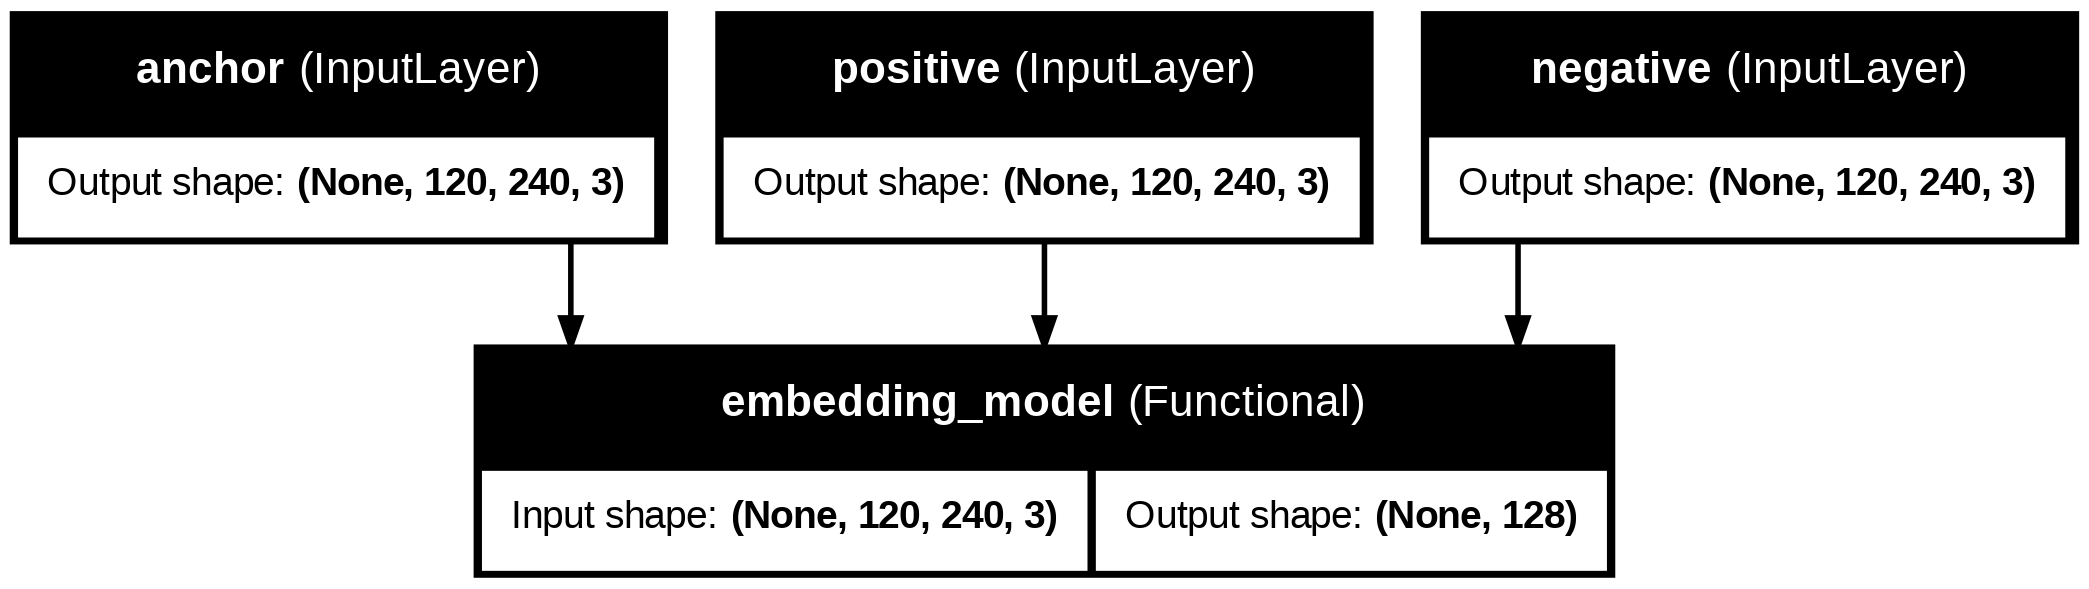

In [31]:
tf.keras.utils.plot_model(
    trainer.siamese_network,
    show_shapes=True,
    show_layer_names=True,
)

In [32]:
trainer.siamese_network.summary()

Model: "siamese_triplet_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ anchor (InputLayer) │ (None, 120, 240,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positive            │ (None, 120, 240,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ negative            │ (None, 120, 240,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_model     │ (None, 128)       │  2,620,352 │ anchor[0][0],     │
│ (Functional)        │                   │            │ positive[0][0],   │
│                     │                   │            │ negative[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,620,352 (10.00 MB)

 Trainable params: 2,223,040 (8.48 MB)

 Non-trainable params: 397,312 (1.52 MB)

In [33]:
trainer.embedding_model.summary()

Model: "embedding_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 120, 240, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 4, 8, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ l2_normalization                │ (None, 128)            │             0 │
│ (L2Normalization)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,620,352 (10.00 MB)

 Trainable params: 2,223,040 (8.48 MB)

 Non-trainable params: 397,312 (1.52 MB)

In [34]:
trainer.compile(
    loss=TripletLoss(margin=0.4),
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    metrics=[
        tf.keras.metrics.Mean(name="ap_sim"),
        tf.keras.metrics.Mean(name="an_sim"),
        tf.keras.metrics.Mean(name="margin"),
        tf.keras.metrics.Mean(name="triplet_acc"),
    ],
)

In [ ]:
'''
trainer.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    metrics = [
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.AUC(curve="PR", name="pr_auc"),
    ]
)
'''

In [43]:
callbacks = get_default_callbacks(
    model_name="mobile_siamese_triplet",
    monitor="val_loss",
    mode="min",
    patience=4,
    start_from_epoch=5,
    reduce_lr_patience=2,
)

In [44]:
history = trainer.train_model(
    epochs=config.training.epochs,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
554/557 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - an_sim: -0.0048 - ap_sim: 0.0633 - loss: 0.3363 - margin: 0.0681 - triplet_acc: 0.6355
Epoch 1: val_loss improved from None to 0.33158, saving model to checkpoints/mobile_siamese_triplet/best.weights.h5

Epoch 1: finished saving model to checkpoints/mobile_siamese_triplet/best.weights.h5
557/557 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - an_sim: -0.0129 - ap_sim: 0.0767 - loss: 0.3175 - margin: 0.0897 - triplet_acc: 0.6613 - val_an_sim: 0.0823 - val_ap_sim: 0.1541 - val_loss: 0.3316 - val_margin: 0.0718 - val_triplet_acc: 0.6604 - learning_rate: 1.0000e-05
Epoch 2/30
555/557 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - an_sim: -0.0263 - ap_sim: 0.1204 - loss: 0.2769 - margin: 0.1467 - triplet_acc: 0.7161
Epoch 2: val_loss improved from 0.33158 to 0.30355, saving model to checkpoints/mobile_siamese_triplet/best.weights.h5

Epoch 2: finished saving model to checkpoints/mobile_siamese_triplet/best.weights.h5
557/557 ━━━━━━━━━━━━━━━━━━━━ 16s 28ms/ste

In [35]:
def plot_keras_history(history: tf.keras.callbacks.History):

    df = pd.DataFrame(history.history)

    metrics = [col for col in df.columns if not col.startswith("val_")]

    n_metrics = len(metrics)
    n_cols = 2
    n_rows = math.ceil(n_metrics / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
    axes = axes.flatten()

    for i, metric in enumerate(metrics):
        ax = axes[i]

        ax.plot(df[metric], label=f"train_{metric}")

        val_metric = f"val_{metric}"
        if val_metric in df.columns:
            ax.plot(df[val_metric], label=f"val_{metric}")

        ax.set_title(metric)
        ax.set_xlabel("Epoch")
        ax.legend()

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

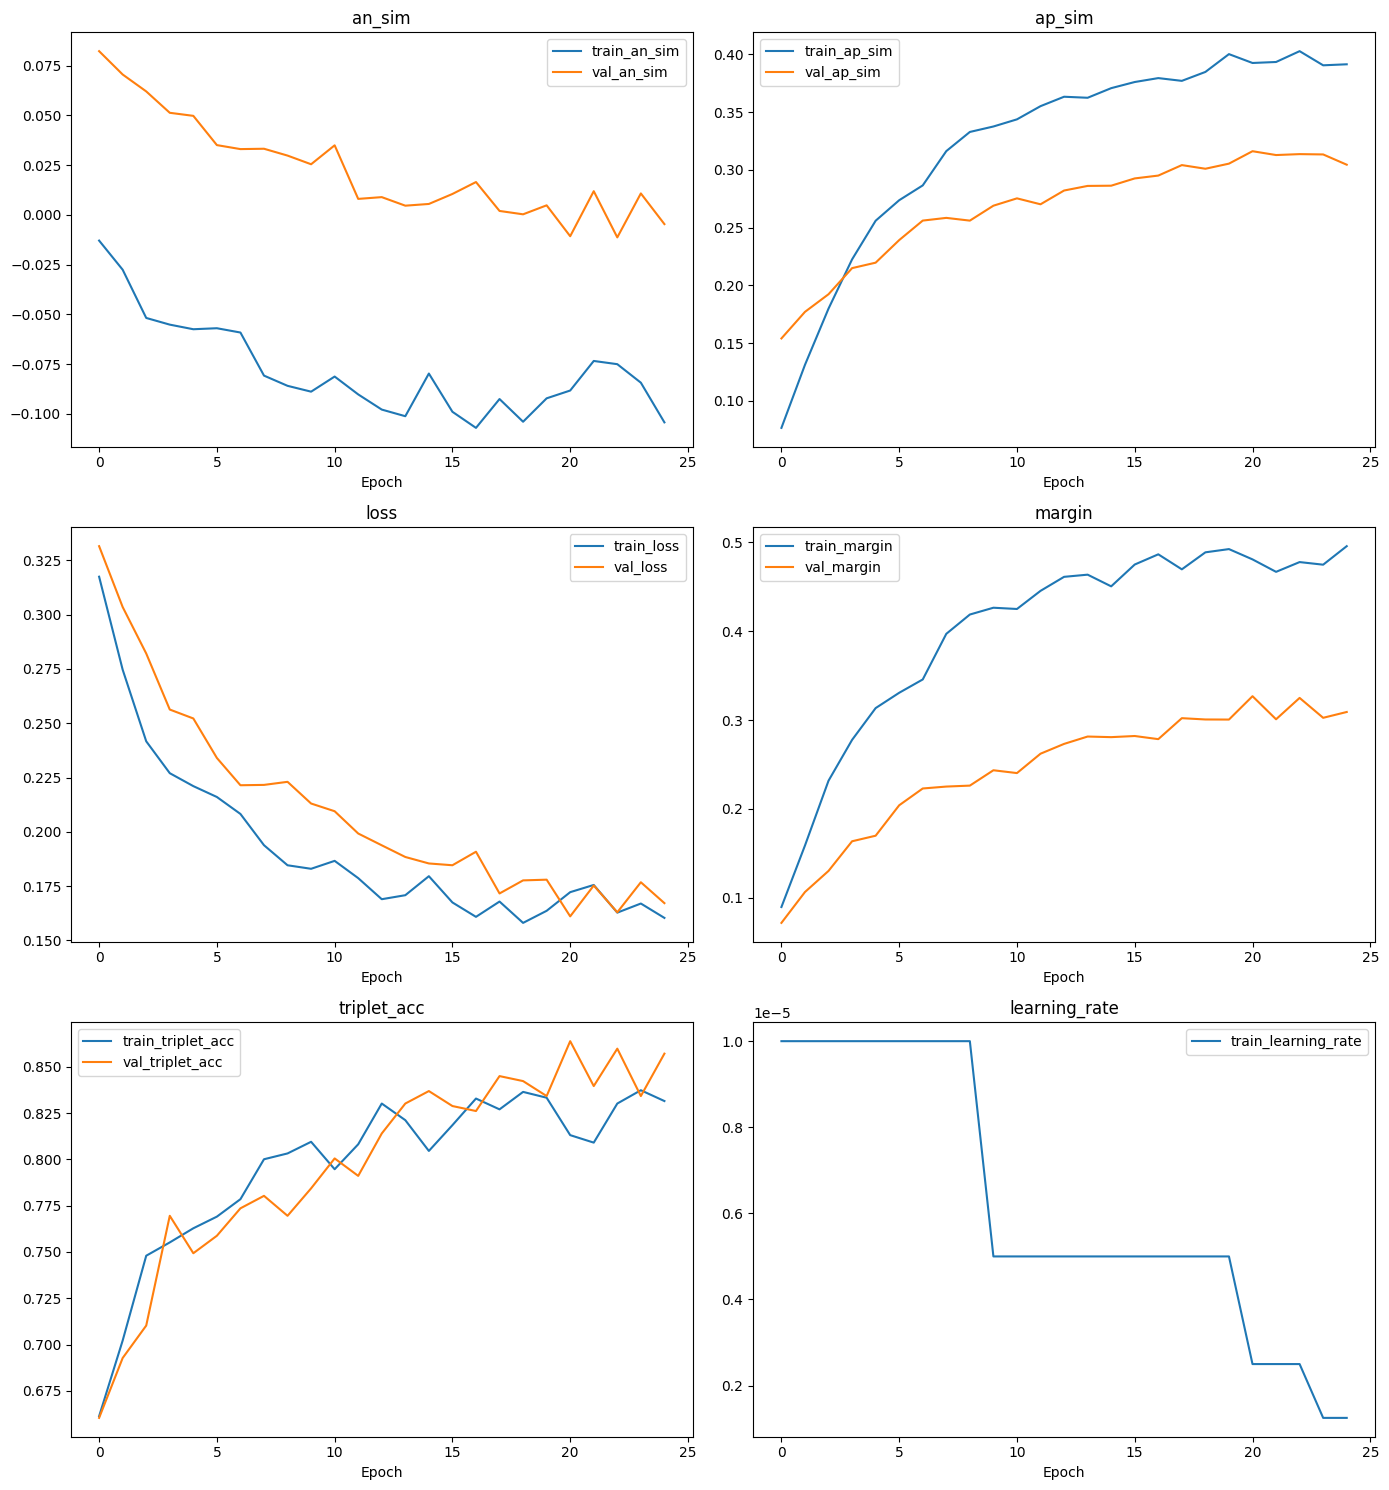

In [46]:
plot_keras_history(history)

In [47]:
os.makedirs("./models", exist_ok=True)
trainer.siamese_network.save(f"./models/mobilenet_siamese_model_5_{config.current_time}.keras")
trainer.embedding_model.save(f"./models/mobilenet_embedding_model_5_{config.current_time}.keras")

In [36]:
trainer.siamese_network.load_weights("./models/mobilenet_siamese_model_5_20260330-171114.keras")

In [37]:
metrics_val = trainer.evaluate_dict(val_triplet)
logger.info(f"{metrics_val}")

186/186 ━━━━━━━━━━━━━━━━━━━━ 38s 90ms/step - an_sim: 0.0083 - ap_sim: 0.3066 - loss: 0.1785 - margin: 0.2983 - triplet_acc: 0.8288
20:04:04 - mobile_test_5_4 - INFO - {'an_sim': 0.008280736394226551, 'ap_sim': 0.30659690499305725, 'loss': 0.17846934497356415, 'margin': 0.2983161211013794, 'triplet_acc': 0.828840970993042}


In [38]:
metrics_test = trainer.evaluate_dict(test_triplet)
logger.info(f"{metrics_test}")

55/55 ━━━━━━━━━━━━━━━━━━━━ 14s 260ms/step - an_sim: -0.0413 - ap_sim: 0.3554 - loss: 0.1249 - margin: 0.3968 - triplet_acc: 0.8940
20:04:35 - mobile_test_5_4 - INFO - {'an_sim': -0.041327882558107376, 'ap_sim': 0.35544058680534363, 'loss': 0.12485558539628983, 'margin': 0.3967684805393219, 'triplet_acc': 0.8940092325210571}


In [39]:
def build_author_confusion_matrix(
    df: pd.DataFrame,
    true_col: str = "author_i",
    pred_col: str = "author_j"
) -> pd.DataFrame:
    authors = sorted(df[true_col].unique())

    cm = confusion_matrix(
        df[true_col],
        df[pred_col],
        labels=authors
    )

    cm_df = pd.DataFrame(
        cm,
        index=authors,
        columns=authors
    )

    return cm_df

In [40]:
def display_heatmap(df: pd.DataFrame) -> None:
    plt.figure(figsize=(10, 8))
    sns.heatmap(df, cmap="Blues", linewidths=0.5)

    plt.xlabel("Predicted Author")
    plt.ylabel("True Author")
    plt.title("Confusion Matrix")
    plt.show()

In [41]:
triplet_evaluator = TripletEvaluator(
    model=trainer,
    logger=logger,
)

In [42]:
triplet_evaluator.data_generator = test_triplet

In [43]:
triplet_report = triplet_evaluator.evaluate()

20:04:49 - mobile_test_5_4 - INFO - === Triplet Evaluation Started ===
20:04:50 - mobile_test_5_4 - INFO - === Collecting triplet results ===
20:04:58 - mobile_test_5_4 - INFO - Total triplets collected: 55
20:04:58 - mobile_test_5_4 - INFO - [LOCAL] acc=0.8894 gap=0.4248 error=0.1106 auc=0.9061
20:04:58 - mobile_test_5_4 - INFO - === Computing global metrics ===
20:04:58 - mobile_test_5_4 - INFO - === Global metrics computed ===
20:04:58 - mobile_test_5_4 - INFO - === Triplet Evaluation Finished ===


In [44]:
triplet_report.local_metrics.auc, triplet_report.local_metrics.triplet_accuracy

(0.9061351908088938, 0.8894009216589862)

In [45]:
triplet_report.global_metrics.df_by_score

,anchor_label,pred_label,accuracy,mean_gap,count,gap_norm,score
0,0,0,1.0,0.578246,36,0.903260,0.903260
1,1,1,1.0,0.443606,38,0.729111,0.729111
2,2,2,1.0,0.653039,46,1.000000,1.000000
3,3,3,1.0,0.374545,39,0.639784,0.639784
4,4,4,1.0,0.358597,34,0.619156,0.619156


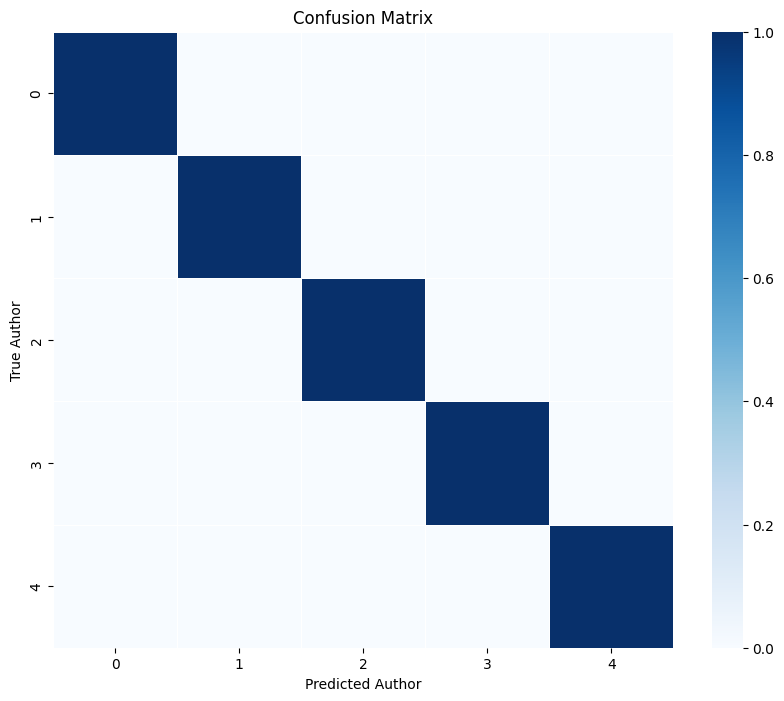

In [46]:
cm_df = build_author_confusion_matrix(
    triplet_report.global_metrics.df_by_score,
    true_col="anchor_label",
    pred_col="pred_label"
)
display_heatmap(cm_df)

In [47]:
train_gen = DataGenerator(
    split=train,
    batch_size=config.batch.train,
    seed=config.training.seed,
    augment=augment_train
)
val_gen = DataGenerator(
    split=val,
    batch_size=config.batch.validation,
    seed=config.training.seed,
    augment=augment
)
test_gen = DataGenerator(
    split=test,
    batch_size=config.batch.test,
    seed=config.training.seed,
    augment=augment
)

In [48]:
display_generator_info(train_gen)

20:05:10 - mobile_test_5_4 - INFO - Generator: DataGenerator
20:05:10 - mobile_test_5_4 - INFO - Number of samples: 2226
20:05:10 - mobile_test_5_4 - INFO - Batch size: 4
20:05:10 - mobile_test_5_4 - INFO - Steps per epoch: 557
20:05:10 - mobile_test_5_4 - INFO - Shape: (180, 360)
20:05:10 - mobile_test_5_4 - INFO - Number of authors: 5


In [49]:
display_generator_info(val_gen)

20:05:11 - mobile_test_5_4 - INFO - Generator: DataGenerator
20:05:11 - mobile_test_5_4 - INFO - Number of samples: 742
20:05:11 - mobile_test_5_4 - INFO - Batch size: 4
20:05:11 - mobile_test_5_4 - INFO - Steps per epoch: 186
20:05:11 - mobile_test_5_4 - INFO - Shape: (180, 360)
20:05:11 - mobile_test_5_4 - INFO - Number of authors: 5


In [50]:
display_generator_info(test_gen)

20:05:12 - mobile_test_5_4 - INFO - Generator: DataGenerator
20:05:12 - mobile_test_5_4 - INFO - Number of samples: 217
20:05:12 - mobile_test_5_4 - INFO - Batch size: 4
20:05:12 - mobile_test_5_4 - INFO - Steps per epoch: 55
20:05:12 - mobile_test_5_4 - INFO - Shape: (180, 360)
20:05:12 - mobile_test_5_4 - INFO - Number of authors: 5


In [51]:
extractor = EmbeddingExtractor(
    model=trainer.embedding_model,
    logger=logger,
)

In [52]:
strategy_pipeline = StrategyPipeline(
    strategies=[
        OneNNStrategy(), MeanStrategy(), CentroidStrategy(), TopKStrategy(k=5),
    ],
    aggregators=[PatchAggregator(), VoteAggregator(), ScoreAggregator()],
    logger=logger,
)

In [53]:
emb_evaluator = EmbeddingEvaluator(
    extractor=extractor,
    pipeline=strategy_pipeline,
    logger=logger,
    seed=config.training.seed
)

In [54]:
val_gen_results = emb_evaluator.evaluate(val_gen)

20:05:55 - mobile_test_5_4 - INFO - [EmbeddingEvaluator] Starting evaluation
20:05:55 - mobile_test_5_4 - INFO - Extracting embeddings from the model
20:05:55 - mobile_test_5_4 - INFO - Processing 186 batches to extract embeddings
20:06:23 - mobile_test_5_4 - INFO - Extracted embeddings for 742 samples
20:06:23 - mobile_test_5_4 - INFO - [EmbeddingEvaluator] Embeddings shape=(742, 128)
20:06:23 - mobile_test_5_4 - INFO - [EmbeddingEvaluator] Computing intra/inter distances


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


20:06:31 - mobile_test_5_4 - INFO - [EmbeddingEvaluator] Evaluating strategies
20:06:31 - mobile_test_5_4 - INFO - Applying strategy pipeline with 4 strategies and 3 aggregators.
20:06:31 - mobile_test_5_4 - INFO - [EmbeddingEvaluator] Evaluation completed


In [55]:
logger.info(f"Intra distance: {val_gen_results.intra_distance}")
logger.info(f"Inter distance: {val_gen_results.inter_distance}")

for strategy_name, agg_results in val_gen_results.strategy_results.items():

    logger.info(f"Strategy: {strategy_name}")

    for agg_name, result in agg_results.items():
        acc = result.metrics.get("accuracy", np.nan)
        logger.info(f"{agg_name.capitalize()} accuracy: {acc:.4f}")

    logger.info(f"{'-'*40}")

20:07:01 - mobile_test_5_4 - INFO - Intra distance: 0.6859691739082336
20:07:01 - mobile_test_5_4 - INFO - Inter distance: 0.9913914203643799
20:07:01 - mobile_test_5_4 - INFO - Strategy: 1nn
20:07:01 - mobile_test_5_4 - INFO - Patch accuracy: 0.7008
20:07:01 - mobile_test_5_4 - INFO - Vote accuracy: 1.0000
20:07:01 - mobile_test_5_4 - INFO - Score accuracy: 0.6000
20:07:01 - mobile_test_5_4 - INFO - ----------------------------------------
20:07:01 - mobile_test_5_4 - INFO - Strategy: mean
20:07:01 - mobile_test_5_4 - INFO - Patch accuracy: 0.7035
20:07:01 - mobile_test_5_4 - INFO - Vote accuracy: 0.8000
20:07:01 - mobile_test_5_4 - INFO - Score accuracy: 0.6000
20:07:01 - mobile_test_5_4 - INFO - ----------------------------------------
20:07:01 - mobile_test_5_4 - INFO - Strategy: centroid
20:07:01 - mobile_test_5_4 - INFO - Patch accuracy: 0.7925
20:07:01 - mobile_test_5_4 - INFO - Vote accuracy: 1.0000
20:07:01 - mobile_test_5_4 - INFO - Score accuracy: 0.6000
20:07:01 - mobile_te

In [56]:
test_gen_results = emb_evaluator.evaluate(test_gen)

20:07:09 - mobile_test_5_4 - INFO - [EmbeddingEvaluator] Starting evaluation
20:07:09 - mobile_test_5_4 - INFO - Extracting embeddings from the model
20:07:09 - mobile_test_5_4 - INFO - Processing 55 batches to extract embeddings
20:07:18 - mobile_test_5_4 - INFO - Extracted embeddings for 217 samples
20:07:18 - mobile_test_5_4 - INFO - [EmbeddingEvaluator] Embeddings shape=(217, 128)
20:07:18 - mobile_test_5_4 - INFO - [EmbeddingEvaluator] Computing intra/inter distances


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


20:07:18 - mobile_test_5_4 - INFO - [EmbeddingEvaluator] Evaluating strategies
20:07:18 - mobile_test_5_4 - INFO - Applying strategy pipeline with 4 strategies and 3 aggregators.
20:07:18 - mobile_test_5_4 - INFO - [EmbeddingEvaluator] Evaluation completed


In [57]:
logger.info(f"Intra distance: {test_gen_results.intra_distance}")
logger.info(f"Inter distance: {test_gen_results.inter_distance}")

for strategy_name, agg_results in test_gen_results.strategy_results.items():

    logger.info(f"Strategy: {strategy_name}")

    for agg_name, result in agg_results.items():
        acc = result.metrics.get("accuracy", np.nan)
        logger.info(f"{agg_name.capitalize()} accuracy: {acc:.4f}")

    logger.info(f"{'-'*40}")

20:07:18 - mobile_test_5_4 - INFO - Intra distance: 0.6521351337432861
20:07:18 - mobile_test_5_4 - INFO - Inter distance: 1.048305630683899
20:07:18 - mobile_test_5_4 - INFO - Strategy: 1nn
20:07:18 - mobile_test_5_4 - INFO - Patch accuracy: 0.8940
20:07:18 - mobile_test_5_4 - INFO - Vote accuracy: 1.0000
20:07:18 - mobile_test_5_4 - INFO - Score accuracy: 0.4000
20:07:18 - mobile_test_5_4 - INFO - ----------------------------------------
20:07:18 - mobile_test_5_4 - INFO - Strategy: mean
20:07:18 - mobile_test_5_4 - INFO - Patch accuracy: 0.8065
20:07:18 - mobile_test_5_4 - INFO - Vote accuracy: 1.0000
20:07:18 - mobile_test_5_4 - INFO - Score accuracy: 0.6000
20:07:18 - mobile_test_5_4 - INFO - ----------------------------------------
20:07:18 - mobile_test_5_4 - INFO - Strategy: centroid
20:07:18 - mobile_test_5_4 - INFO - Patch accuracy: 0.8618
20:07:18 - mobile_test_5_4 - INFO - Vote accuracy: 1.0000
20:07:18 - mobile_test_5_4 - INFO - Score accuracy: 0.8000
20:07:18 - mobile_tes

In [58]:
viz = EmbeddingVisualizer(
    report=test_gen_results,
    logger=logger,
    loader=test.loader,
)

In [59]:
viz.set_strategy("1nn")

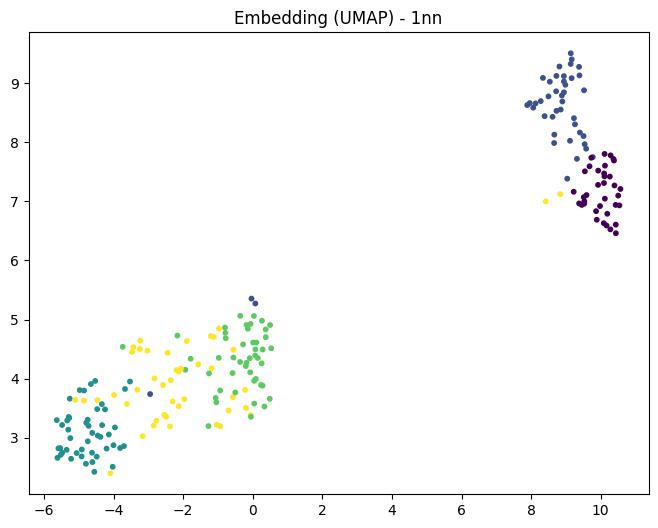

In [60]:
viz.plot_embeddings_2d()

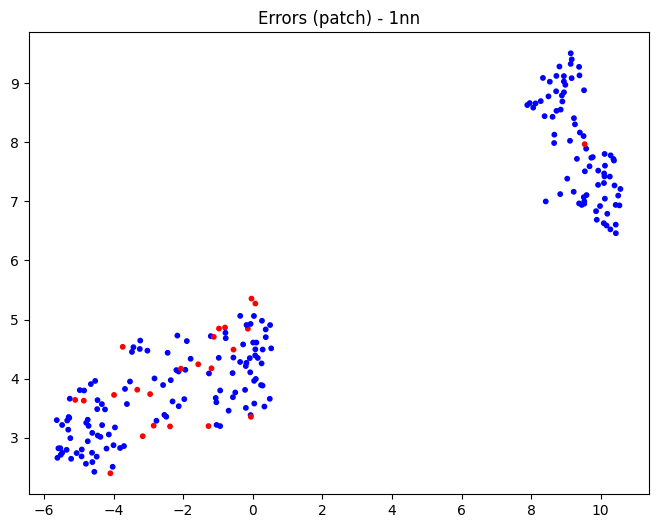

In [61]:
viz.plot_errors_2d(level="patch")

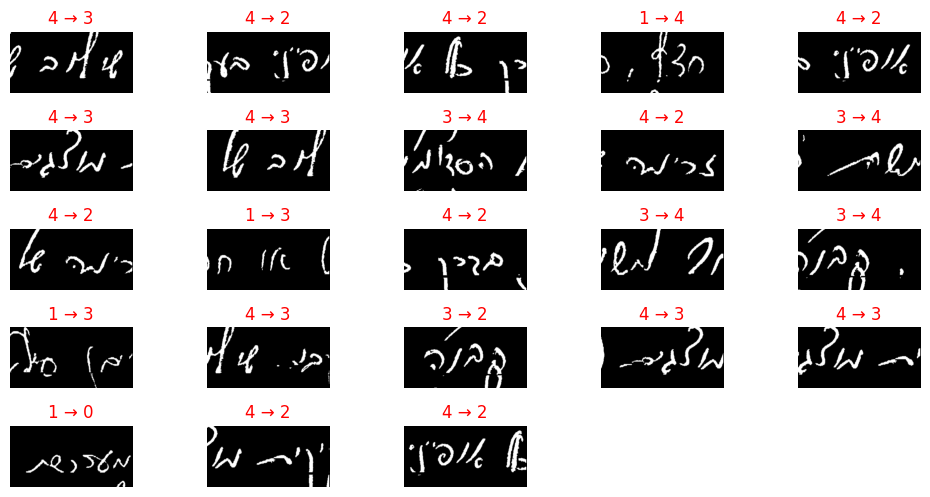

In [62]:
viz.plot_error_images()

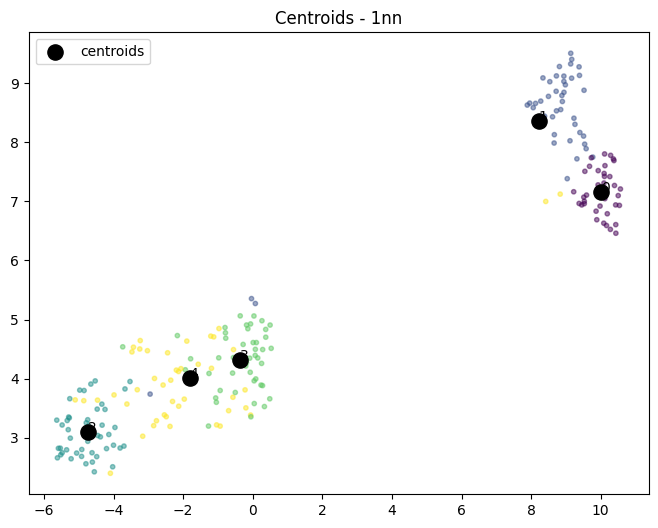

In [63]:
viz.plot_centroids()

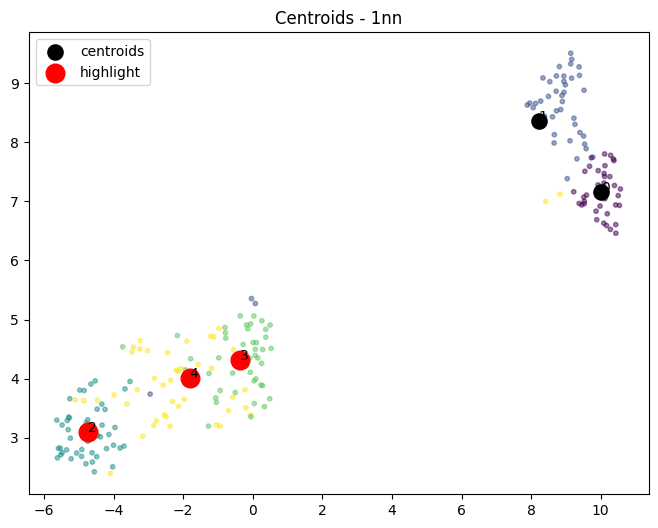

In [64]:
viz.plot_centroids([2, 3, 4])

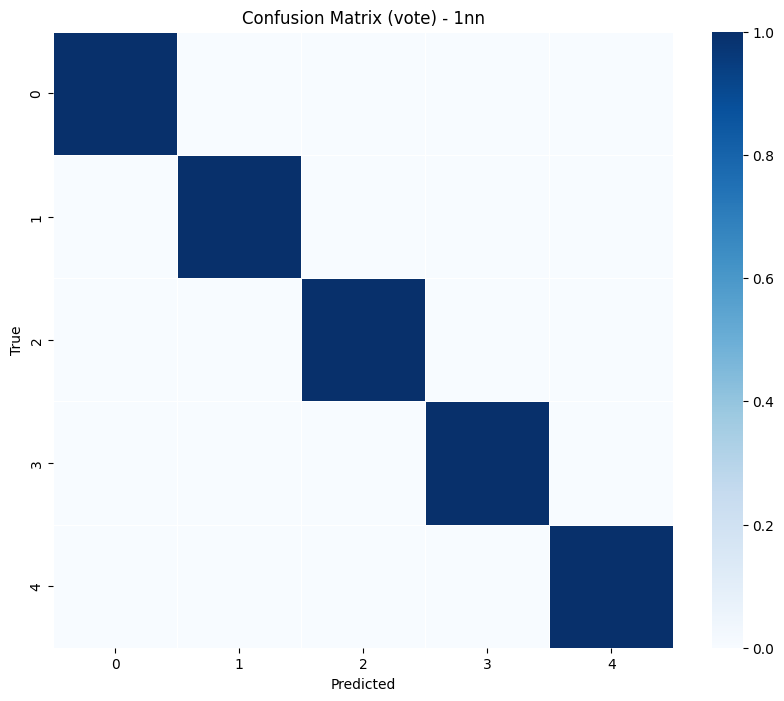

In [65]:
viz.plot_confusion(level="vote")

In [66]:
viz.set_strategy(strategy="centroid")

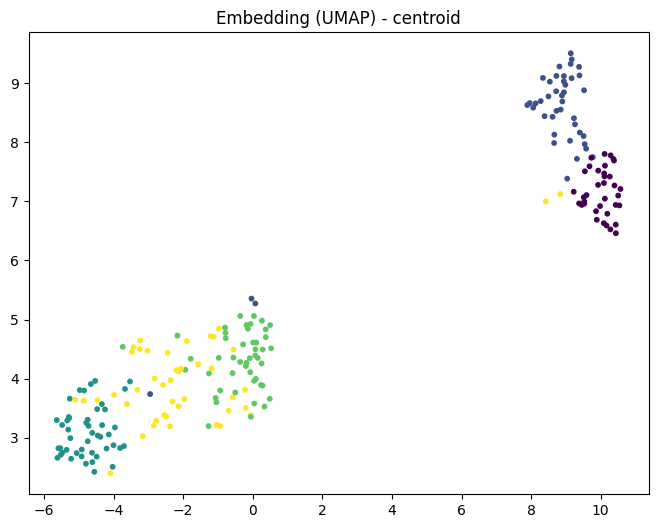

In [67]:
viz.plot_embeddings_2d()

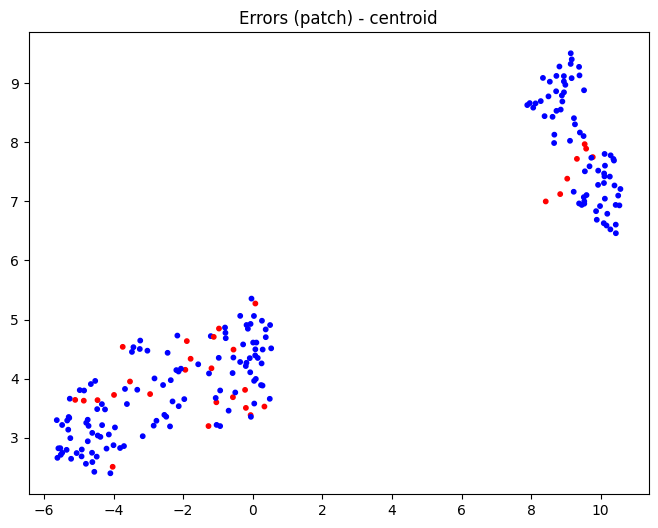

In [68]:
viz.plot_errors_2d(level="patch")

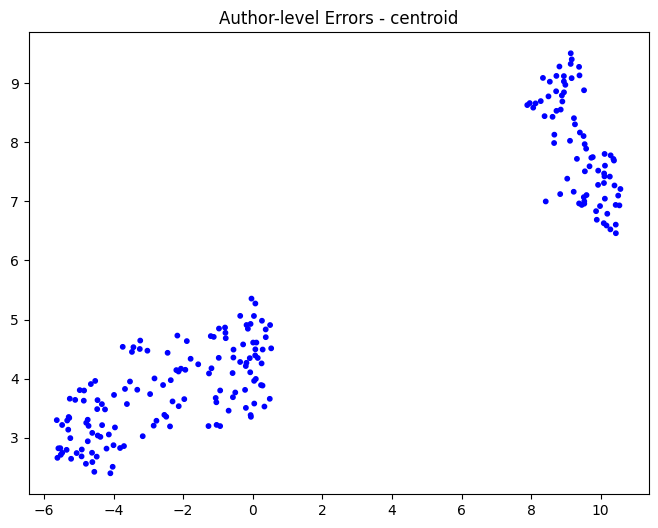

In [69]:
viz.plot_author_errors_2d()

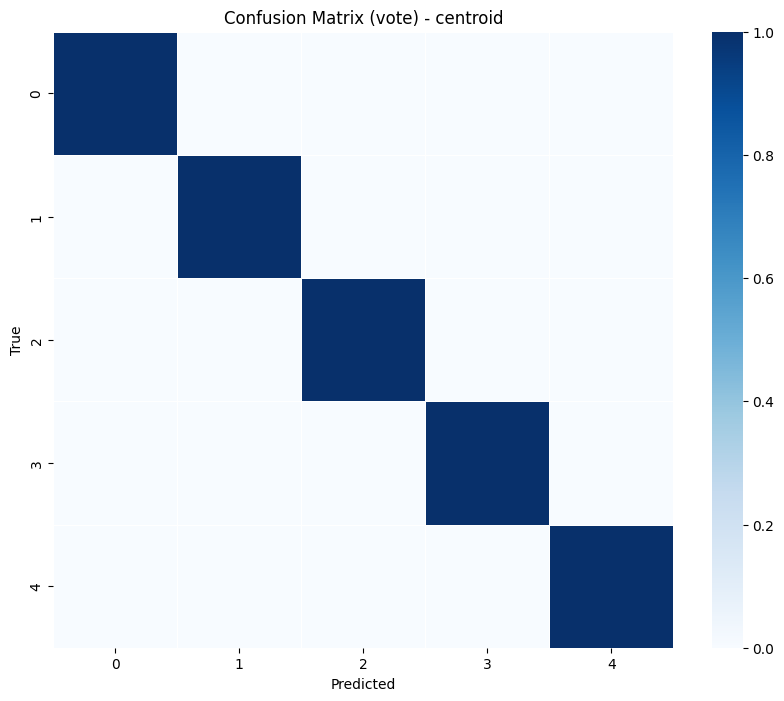

In [70]:
viz.plot_confusion("vote")

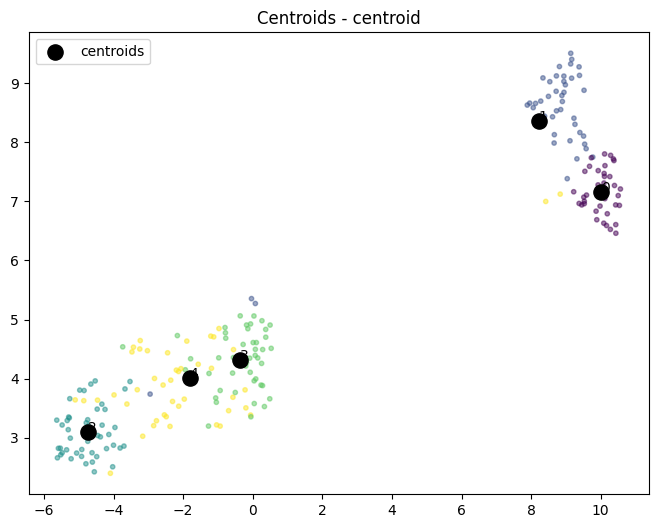

In [71]:
viz.plot_centroids()